# Indego Philadelphia Bike Share — Descriptive Analytics

**Author:** Naval Katoch  
**Data:** Indego trip data, 2022–2025 (Philadelphia, PA)  
**Source:** https://www.rideindego.com/about/data/

---

This notebook explores Philadelphia's Indego bike share system across four years of modern trip data. It is a modernised rebuild of an earlier NYC CitiBike analysis which I had done as a part of a Data Science Bootcamp when I was working at IBM. This project is updated with a Philadelphia lens, and new features like e-bike vs. pedal comparisons.

**Narrative arc:** Where do rides happen? → When? → Who is riding? → What bike? → What suppresses demand? → What are the most popular routes?

### Contents
1. Setup & Data Loading
2. System Growth (2022–2025)
3. Station Demand Map
4. Ride Timing: Hour × Day-of-Week Heatmap
5. Commuter vs. Recreational Patterns
6. Trip Duration by Passholder Type
7. E-Bike vs. Pedal Bike Analysis
8. Weather Impact on Ridership
9. Most Popular Routes Map

## 1. Setup & Data Loading

In [1]:
import sys
import os

# Make src/ importable and set working directory to project root
project_root = os.path.abspath('..')
sys.path.insert(0, os.path.join(project_root, 'src'))
os.chdir(project_root)

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from IPython.display import display, HTML
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

# Consistent plot style throughout
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

In [2]:
# -------------------------------------------------------------------
# STEP 1 (run once): download Indego quarterly CSVs to data/
# Skip this cell if you have already downloaded the data.
# See data/README.md for manual download instructions.
# -------------------------------------------------------------------
from data_loader import download_all
download_all(start_year=2022, end_year=2025)

  indego-trips-2022-q1.csv already exists, skipping.
  indego-trips-2022-q2.csv already exists, skipping.
  indego-trips-2022-q3.csv already exists, skipping.
  indego-trips-2022-q4.csv already exists, skipping.
  indego-trips-2023-q1.csv already exists, skipping.
  indego-trips-2023-q2.csv already exists, skipping.
  indego-trips-2023-q3.csv already exists, skipping.
  indego-trips-2023-q4.csv already exists, skipping.
  indego-trips-2024-q1.csv already exists, skipping.
  indego-trips-2024-q2.csv already exists, skipping.
  indego-trips-2024-q3.csv already exists, skipping.
  indego-trips-2024-q4.csv already exists, skipping.
  indego-trips-2025-q1.csv already exists, skipping.
  indego-trips-2025-q2.csv already exists, skipping.
  indego-trips-2025-q3.csv already exists, skipping.
  indego-trips-2025-q4.csv already exists, skipping.


In [3]:
from data_loader import load_trips, fetch_weather

df = load_trips(start_year=2022, end_year=2025)
print(f"Total trips loaded : {len(df):,}")
print(f"Columns            : {list(df.columns)}")
df.head(3)

Total trips loaded : 4,617,900
Columns            : ['trip_id', 'duration', 'start_time', 'end_time', 'start_station', 'start_lat', 'start_lon', 'end_station', 'end_lat', 'end_lon', 'bike_id', 'plan_duration', 'trip_route_category', 'passholder_type', 'bike_type']


,trip_id,duration,start_time,end_time,start_station,start_lat,start_lon,end_station,end_lat,end_lon,bike_id,plan_duration,trip_route_category,passholder_type,bike_type
0,453457286,4,2022-01-01 00:04:00,2022-01-01 00:08:00,3045,39.947922,-75.162369,3063,39.946331,-75.169800,3696,365,One Way,Indego365,standard
1,453457285,7,2022-01-01 00:06:00,2022-01-01 00:12:00,3031,39.980049,-75.155220,3017,39.980030,-75.143707,17642,365,One Way,Indego365,electric
2,453457284,6,2022-01-01 00:07:00,2022-01-01 00:13:00,3010,39.947109,-75.166183,3244,39.938648,-75.166740,14657,30,One Way,Indego30,standard


In [4]:
# --- Feature engineering ---

# Time components
df['hour']           = df['start_time'].dt.hour
df['day_of_week']    = df['start_time'].dt.day_name()
df['quarter']        = df['start_time'].dt.to_period('Q')
df['quarter_str']    = df['quarter'].astype(str)
df['date']           = df['start_time'].dt.normalize()

# Standardise free-text categoricals
df['bike_type']             = df['bike_type'].str.strip().str.lower()
df['trip_route_category']   = df['trip_route_category'].str.strip()
df['passholder_type']       = df['passholder_type'].str.strip()

print("Bike types:\n",           df['bike_type'].value_counts().to_string())
print("\nTrip categories:\n",    df['trip_route_category'].value_counts().to_string())
print("\nPassholder types:\n",   df['passholder_type'].value_counts().to_string())
print(f"\nDate range: {df['start_time'].min().date()} → {df['start_time'].max().date()}")

Bike types:
 bike_type
electric    2584939
standard    2032961

Trip categories:
 trip_route_category
One Way       4310259
Round Trip     307641

Passholder types:
 passholder_type
Indego30      2800519
Indego365     1451532
Day Pass       240503
Walk-up        123728
IndegoFlex          5

Date range: 2022-01-01 → 2025-12-31


---
## 2. System Growth (2022–2025)

Indego hit a record **1.3 million trips in 2024**, up 14% year-over-year. The chart below shows quarterly momentum across our analysis window.

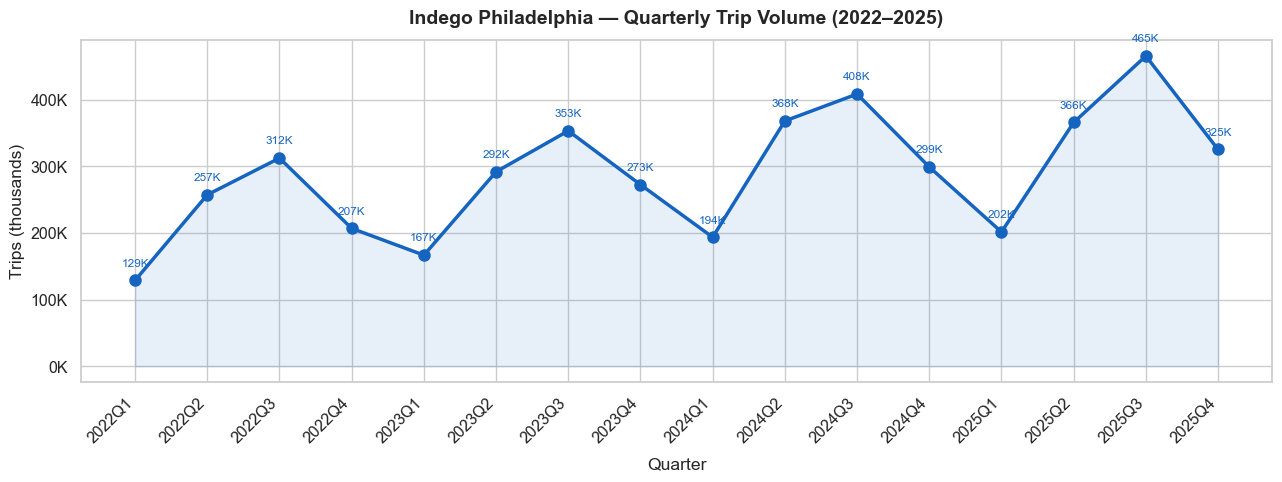

In [5]:
quarterly = (
    df.groupby('quarter_str')
    .size()
    .reset_index(name='trips')
    .sort_values('quarter_str')
)

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(quarterly))

ax.plot(x, quarterly['trips'] / 1_000, marker='o', linewidth=2.5,
        markersize=8, color='#1565C0', zorder=3)
ax.fill_between(x, quarterly['trips'] / 1_000, alpha=0.10, color='#1565C0')

# Annotate each point
for xi, (_, row) in zip(x, quarterly.iterrows()):
    ax.annotate(f"{row['trips']/1000:.0f}K",
                xy=(xi, row['trips']/1000),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8.5, color='#1565C0')

ax.set_xticks(x)
ax.set_xticklabels(quarterly['quarter_str'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}K'))
ax.set_xlabel('Quarter', labelpad=8)
ax.set_ylabel('Trips (thousands)')
ax.set_title('Indego Philadelphia — Quarterly Trip Volume (2022–2025)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## 3. Station Demand Map

Each circle represents an Indego station. Circle size scales with total trips originating from that station. Hover for exact counts.

In [6]:
station_vol = (
    df.dropna(subset=['start_lat', 'start_lon'])
    .groupby(['start_station', 'start_lat', 'start_lon'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
)

print(f"Stations with data: {len(station_vol)}")
print("Top 5 stations by trip volume:")
print(station_vol.head())

m_stations = folium.Map(
    location=[39.9526, -75.1652],
    zoom_start=13,
    tiles='CartoDB positron'
)

max_count = station_vol['trip_count'].max()

for _, row in station_vol.iterrows():
    radius = 4 + (row['trip_count'] / max_count) * 22
    folium.CircleMarker(
        location=[row['start_lat'], row['start_lon']],
        radius=radius,
        color='#C62828',
        weight=1,
        fill=True,
        fill_color='#E53935',
        fill_opacity=0.65,
        tooltip=(
            f"<b>Station {row['start_station']}</b><br>"
            f"{row['trip_count']:,} trips originated here"
        )
    ).add_to(m_stations)

display(HTML(m_stations._repr_html_()))

Stations with data: 335
Top 5 stations by trip volume:
     start_station  start_lat  start_lon  trip_count
7             3010  39.947109 -75.166183       81393
27            3032  39.945271 -75.179710       64716
45            3054  39.962502 -75.174202       52767
17            3020  39.948551 -75.190071       51058
137           3208  39.950481 -75.193237       50990


---
## 3.5 Bike Inventory Imbalance — the rebalancing problem

Trip volume alone doesn't reveal why Indego needs cargo vans every morning. The real problem is **net flow**: the difference between bikes leaving a station and bikes arriving at it during the same rush window.

During AM rush (7–9am), residential stations bleed bikes as commuters head downtown; bikes accumulate at Center City and University City stations. Indego pays drivers to manually rebalance — a cost of roughly \$246K/year industry-wide for comparable systems.

The chart below shows average AM and PM session net flow for the top 50 highest-volume stations, sorted by AM net flow. Red bars = stations that drain (need bikes pre-positioned). Blue bars = stations that fill (need bikes collected). Notebook 02 forecasts this net flow per station per session, enabling proactive dispatch.

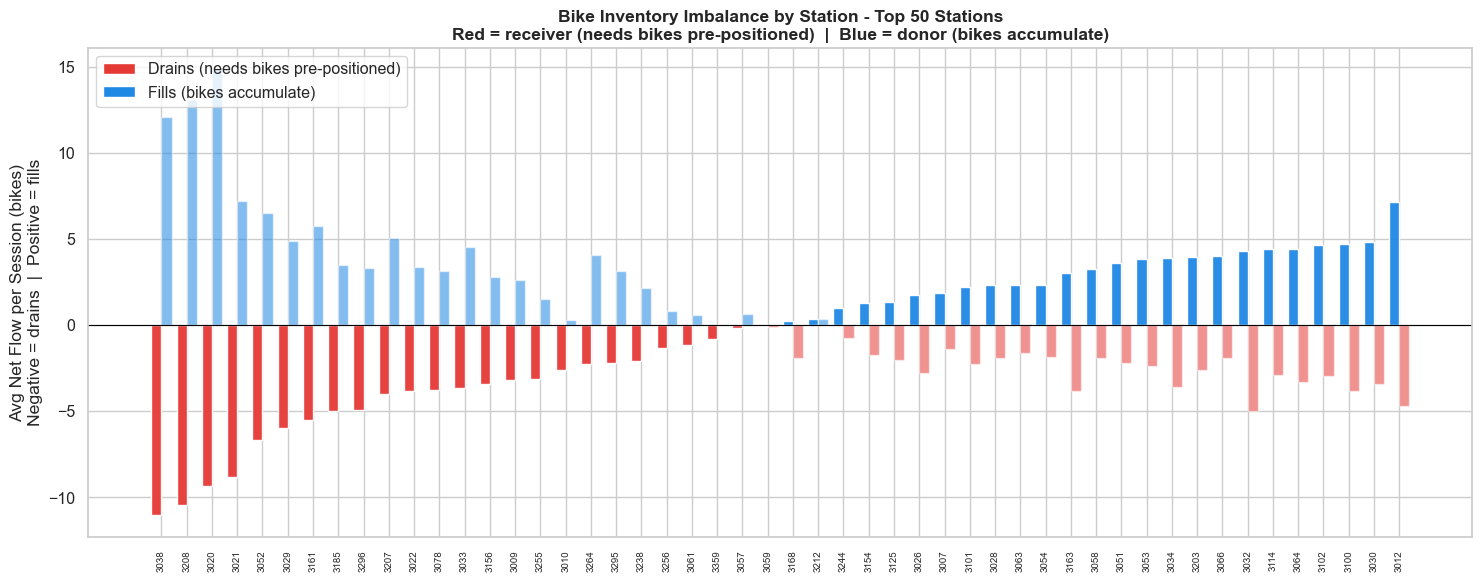

Stations that drain during AM rush (avg net flow < -2): 20
Stations that fill during AM rush (avg net flow > +2): 18
Max drain: -11.0 bikes/session  |  Max fill: 7.2 bikes/session

=> Notebook 02 forecasts this net flow at session level for proactive rebalancing.


In [7]:
from matplotlib.patches import Patch

# --- Compute hourly departures + arrivals ---
trips_h = df[['start_station', 'end_station', 'start_time', 'end_time']].copy()
trips_h['start_hour'] = trips_h['start_time'].dt.floor('h')
trips_h['end_hour']   = trips_h['end_time'].dt.floor('h')

departures = (
    trips_h.groupby(['start_station', 'start_hour']).size()
    .reset_index(name='departures')
    .rename(columns={'start_station': 'station_id', 'start_hour': 'hour_slot'})
)
arrivals = (
    trips_h.groupby(['end_station', 'end_hour']).size()
    .reset_index(name='arrivals')
    .rename(columns={'end_station': 'station_id', 'end_hour': 'hour_slot'})
)
flow = departures.merge(arrivals, on=['station_id', 'hour_slot'], how='outer').fillna(0)
flow['station_id'] = flow['station_id'].astype(int)
flow['hour']       = flow['hour_slot'].dt.hour
flow['net_flow']   = flow['departures'] - flow['arrivals']

AM_HOURS = [7, 8, 9]
PM_HOURS = [16, 17, 18, 19]
rush = flow[flow['hour'].isin(AM_HOURS + PM_HOURS)].copy()
rush['session']      = rush['hour'].apply(lambda h: 'AM' if h in AM_HOURS else 'PM')
rush['session_date'] = rush['hour_slot'].dt.normalize()

# Top 50 stations by total rush-hour departures
top50 = rush.groupby('station_id')['departures'].sum().nlargest(50).index.tolist()

# Aggregate to session level then average across all sessions per (station, AM/PM)
session_flow = (
    rush[rush['station_id'].isin(top50)]
    .groupby(['station_id', 'session_date', 'session'])
    .agg(net_flow=('net_flow', 'sum'))
    .reset_index()
)
avg_by_sess = (
    session_flow.groupby(['station_id', 'session'])['net_flow']
    .mean().unstack('session').fillna(0)
).sort_values('AM')

labels  = avg_by_sess.index.astype(str).tolist()
x       = np.arange(len(avg_by_sess))
w       = 0.4
am_vals = avg_by_sess['AM'].values
pm_vals = avg_by_sess['PM'].values

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - w/2, am_vals, w,
       color=['#E53935' if v < 0 else '#1E88E5' for v in am_vals],
       alpha=0.95, label='AM Rush (7-9am)')
ax.bar(x + w/2, pm_vals, w,
       color=['#E53935' if v < 0 else '#1E88E5' for v in pm_vals],
       alpha=0.55, label='PM Rush (4-7pm)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel('Avg Net Flow per Session (bikes)\nNegative = drains  |  Positive = fills')
ax.set_title(
    'Bike Inventory Imbalance by Station - Top 50 Stations\n'
    'Red = receiver (needs bikes pre-positioned)  |  Blue = donor (bikes accumulate)',
    fontweight='bold'
)
legend_elements = [
    Patch(facecolor='#E53935', label='Drains (needs bikes pre-positioned)'),
    Patch(facecolor='#1E88E5', label='Fills (bikes accumulate)'),
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

drains = (am_vals < -2).sum()
fills  = (am_vals > 2).sum()
print(f'Stations that drain during AM rush (avg net flow < -2): {drains}')
print(f'Stations that fill during AM rush (avg net flow > +2): {fills}')
print(f'Max drain: {am_vals.min():.1f} bikes/session  |  Max fill: {am_vals.max():.1f} bikes/session')
print()
print('=> Notebook 02 forecasts this net flow at session level for proactive rebalancing.')

---
## 3.6 Top Station Concentration

Indego operates over 300 stations, but trip volume is highly concentrated. Below: the cumulative share of rush-hour trips by station rank.

The **top 50 stations capture roughly half of all rush-hour trips**. These are the stations where rebalancing actually happens — predicting demand at a low-volume station that sees 2 trips a day has no operational value. This is why Notebook 02 narrows its forecast scope to the top 50.

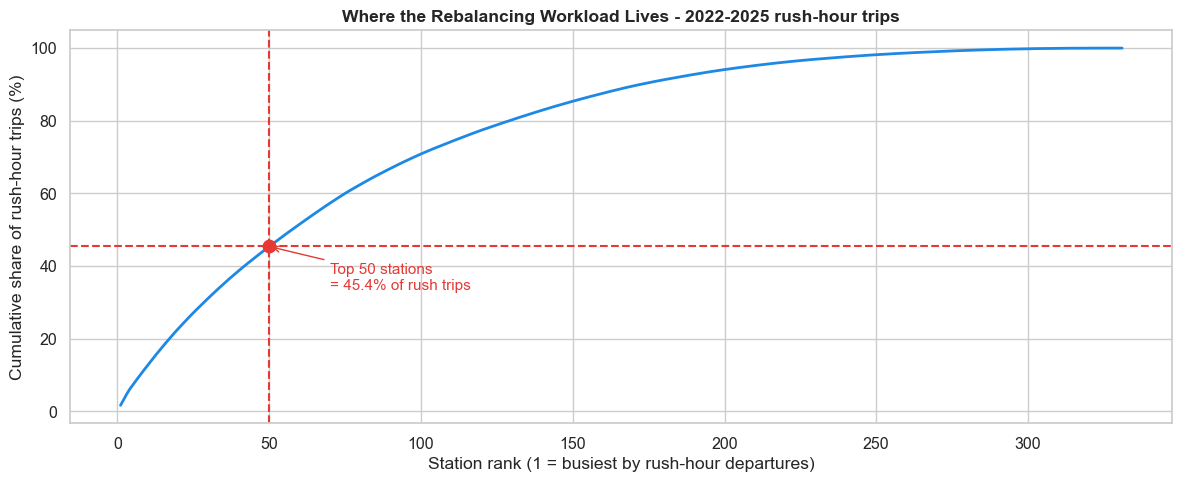

Total stations active during rush hours: 331
Top 50 stations: 45.4% of rush-hour trips
Remaining 281 stations: 54.6% of rush-hour trips


In [8]:
station_vol = (
    rush.groupby('station_id')['departures'].sum()
    .sort_values(ascending=False)
    .reset_index()
)
station_vol['rank']      = range(1, len(station_vol) + 1)
station_vol['cum_share'] = station_vol['departures'].cumsum() / station_vol['departures'].sum()
top50_share = station_vol.loc[station_vol['rank'] == 50, 'cum_share'].values[0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(station_vol['rank'], station_vol['cum_share'] * 100,
        color='#1E88E5', linewidth=2)
ax.axhline(top50_share * 100, color='#E53935', linestyle='--', linewidth=1.5)
ax.axvline(50, color='#E53935', linestyle='--', linewidth=1.5)
ax.scatter([50], [top50_share * 100], color='#E53935', s=80, zorder=5)
ax.annotate(
    f'Top 50 stations\n= {top50_share*100:.1f}% of rush trips',
    xy=(50, top50_share * 100),
    xytext=(70, top50_share * 100 - 12),
    arrowprops=dict(arrowstyle='->', color='#E53935'),
    fontsize=11, color='#E53935'
)
ax.set_xlabel('Station rank (1 = busiest by rush-hour departures)')
ax.set_ylabel('Cumulative share of rush-hour trips (%)')
ax.set_title('Where the Rebalancing Workload Lives - 2022-2025 rush-hour trips',
             fontweight='bold')
plt.tight_layout()
plt.show()

n_total = len(station_vol)
print(f'Total stations active during rush hours: {n_total}')
print(f'Top 50 stations: {top50_share*100:.1f}% of rush-hour trips')
print(f'Remaining {n_total - 50} stations: {(1 - top50_share)*100:.1f}% of rush-hour trips')

---
## 4. Ride Timing: Hour × Day-of-Week Heatmap

The heatmap instantly separates **commuter behaviour** (weekday morning and evening peaks) from **recreational behaviour** (Saturday/Sunday midday plateau).

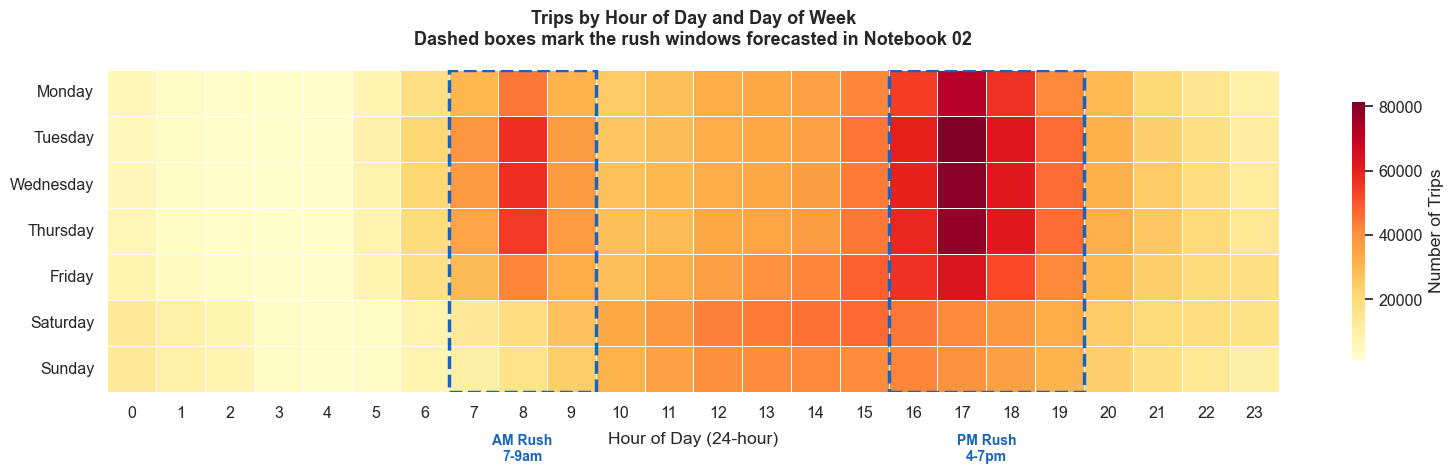

In [23]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (
    df.groupby(['day_of_week', 'hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.4,
    linecolor='white',
    fmt=',d',
    cbar_kws={'label': 'Number of Trips', 'shrink': 0.8}
)

# Highlight Notebook 02's rush windows: AM (7-9am) and PM (4-7pm)
ax.axvspan(7,  10, ymin=0, ymax=1, fill=False, edgecolor='#1565C0',
           linewidth=2.5, linestyle='--')
ax.axvspan(16, 20, ymin=0, ymax=1, fill=False, edgecolor='#1565C0',
           linewidth=2.5, linestyle='--')
ax.text(8.5,  7.9, 'AM Rush\n7-9am', ha='center', va='top', fontsize=10,
         color='#1565C0', fontweight='bold')
ax.text(18,   7.9, 'PM Rush\n4-7pm', ha='center', va='top', fontsize=10,
         color='#1565C0', fontweight='bold')

ax.set_title('Trips by Hour of Day and Day of Week\n'
             'Dashed boxes mark the rush windows forecasted in Notebook 02',
             fontsize=13, fontweight='bold', pad=18)
ax.set_xlabel('Hour of Day (24-hour)', labelpad=8)
ax.set_ylabel('')
ax.set_xticklabels([str(h) for h in range(24)], rotation=0)
plt.tight_layout()
plt.show()

---
## 4.5 Event-Day Snapshot — How Demand Breaks the Pattern

The heatmap above shows the *average* weekly pattern. But average days are easy to predict. The interesting demand swings happen on **exception days**: Phillies and Eagles home games, festivals, holidays.

Below: a side-by-side comparison of Indego trip volume on a **Phillies home-game Monday (Sep 8, 2025)** vs. a **normal Monday (Sep 15, 2025)**. The two days share the same season, weekday, and weather profile — the only difference is the game.

Notebook 02 encodes this signal as typed binary features (`is_phillies_home`, `is_eagles_home`, `is_festival`, `is_academic_event`), which is why ML adds **+10% lift over baseline on Phillies game days** and **+34% on holidays**.

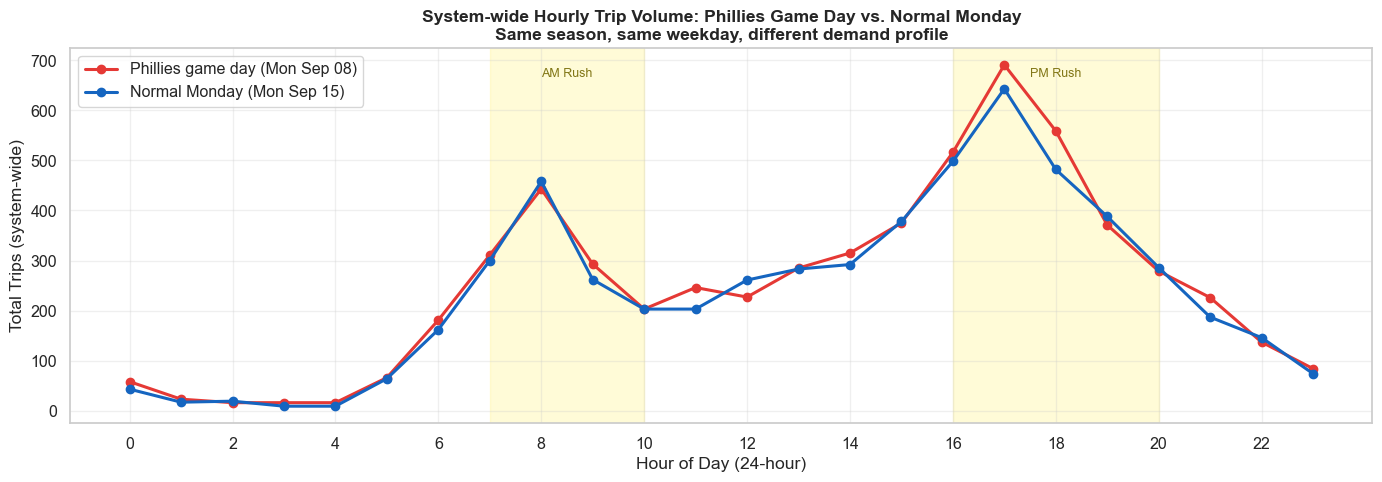

Event day  (2025-09-08): 5,937 trips system-wide
Normal day (2025-09-15): 5,667 trips system-wide
PM rush only: event day 2,137 vs. normal day 2,011 (+6.3% difference)


In [10]:
EVENT_DATE  = pd.Timestamp('2025-09-08')   # Mon - Phillies vs. Mets home game
NORMAL_DATE = pd.Timestamp('2025-09-15')   # Mon - no Phillies home game

trips_day = df[['start_time']].copy()
trips_day['date'] = trips_day['start_time'].dt.normalize()
trips_day['hour'] = trips_day['start_time'].dt.hour

event_hourly  = (
    trips_day[trips_day['date'] == EVENT_DATE]
    .groupby('hour').size().reindex(range(24), fill_value=0)
)
normal_hourly = (
    trips_day[trips_day['date'] == NORMAL_DATE]
    .groupby('hour').size().reindex(range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(event_hourly.index,  event_hourly.values,  marker='o', linewidth=2.2,
        color='#E53935', label=f'Phillies game day ({EVENT_DATE.strftime("%a %b %d")})')
ax.plot(normal_hourly.index, normal_hourly.values, marker='o', linewidth=2.2,
        color='#1565C0', label=f'Normal Monday ({NORMAL_DATE.strftime("%a %b %d")})')

ax.axvspan(7,  10, color='#FFF59D', alpha=0.4, zorder=0)
ax.axvspan(16, 20, color='#FFF59D', alpha=0.4, zorder=0)
ax.text(8.5,  ax.get_ylim()[1]*0.92, 'AM Rush', ha='center', fontsize=9, color='#827717')
ax.text(18,   ax.get_ylim()[1]*0.92, 'PM Rush', ha='center', fontsize=9, color='#827717')

ax.set_xlabel('Hour of Day (24-hour)')
ax.set_ylabel('Total Trips (system-wide)')
ax.set_xticks(range(0, 24, 2))
ax.set_title(
    'System-wide Hourly Trip Volume: Phillies Game Day vs. Normal Monday\n'
    'Same season, same weekday, different demand profile',
    fontweight='bold'
)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

event_total  = event_hourly.sum()
normal_total = normal_hourly.sum()
event_pm     = event_hourly.iloc[16:20].sum()
normal_pm    = normal_hourly.iloc[16:20].sum()
print(f'Event day  ({EVENT_DATE.date()}): {event_total:,} trips system-wide')
print(f'Normal day ({NORMAL_DATE.date()}): {normal_total:,} trips system-wide')
print(f'PM rush only: event day {event_pm:,} vs. normal day {normal_pm:,} '
      f'({(event_pm/normal_pm - 1)*100:+.1f}% difference)')

---
## 5. Commuter vs. Recreational Patterns

Indego records whether each trip is **One Way** (point-to-point, typical of commuting) or **Round Trip** (departure and return to same station, typical of leisure).
Plotting these by hour of day reveals two distinct usage profiles.

> **Connection to Notebook 02:** One-way commute trips create directional bike flow — residential stations drain in the morning, downtown stations fill up. That imbalance (visualized above in Section 3.5) is what the demand forecasting model in Notebook 02 predicts and helps dispatchers preempt.

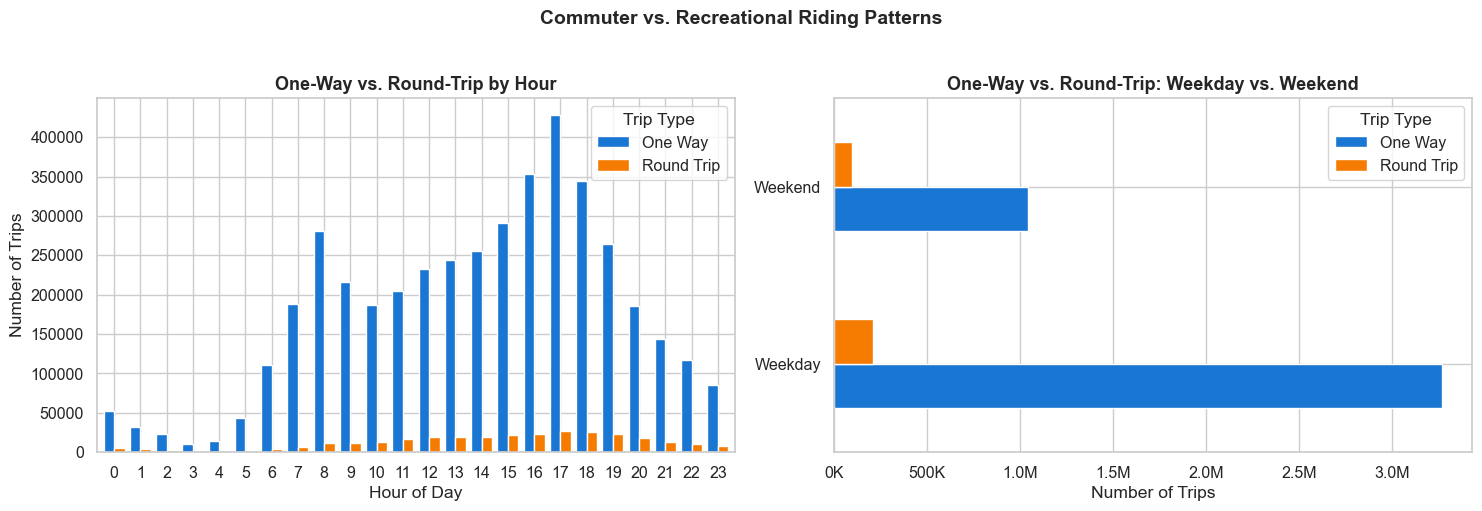

In [11]:
route_hour = (
    df.groupby(['hour', 'trip_route_category'])
    .size()
    .reset_index(name='trips')
)
pivot_route = (
    route_hour
    .pivot(index='hour', columns='trip_route_category', values='trips')
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Panel A: stacked bar by hour ---
pivot_route.plot(
    kind='bar',
    ax=axes[0],
    color=['#1976D2', '#F57C00'],
    width=0.8,
    edgecolor='white'
)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Trips')
axes[0].set_title('One-Way vs. Round-Trip by Hour', fontsize=13, fontweight='bold')
axes[0].legend(title='Trip Type')
axes[0].tick_params(axis='x', rotation=0)

# --- Panel B: weekday vs weekend split ---
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
split = (
    df.groupby(['is_weekend', 'trip_route_category'])
    .size()
    .reset_index(name='trips')
)
split['day_type'] = split['is_weekend'].map({True: 'Weekend', False: 'Weekday'})
pivot_split = split.pivot(index='day_type', columns='trip_route_category', values='trips').fillna(0)

pivot_split.plot(
    kind='barh',
    ax=axes[1],
    color=['#1976D2', '#F57C00'],
    width=0.5,
    edgecolor='white'
)
axes[1].set_xlabel('Number of Trips')
axes[1].set_ylabel('')
axes[1].set_title('One-Way vs. Round-Trip: Weekday vs. Weekend', fontsize=13, fontweight='bold')
axes[1].legend(title='Trip Type')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'))

plt.suptitle('Commuter vs. Recreational Riding Patterns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Trip Duration by Passholder Type

Different membership tiers attract riders with different habits. Annual pass holders tend to make shorter, purposeful trips; casual day-pass users take longer, exploratory rides.

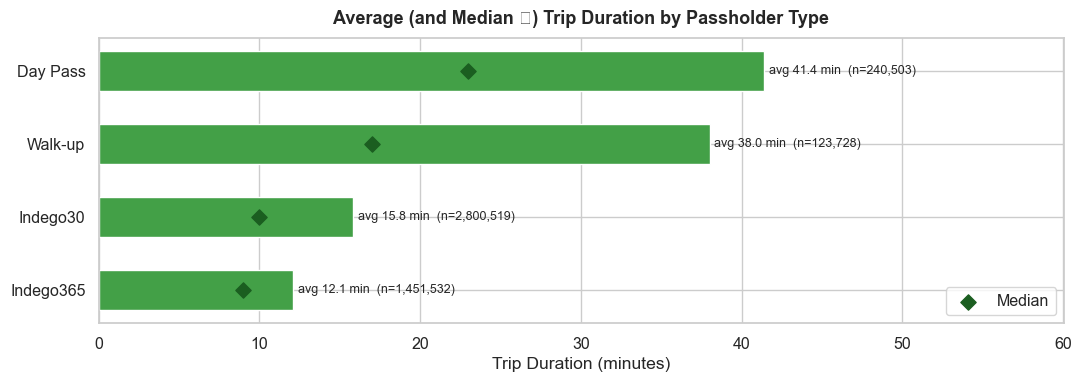

In [12]:
pass_stats = (
    df.groupby('passholder_type')['duration']
    .agg(avg='mean', median='median', count='count')
    .reset_index()
    .query('count > 500')          # drop near-empty categories
    .sort_values('avg', ascending=True)
)

fig, ax = plt.subplots(figsize=(11, max(4, len(pass_stats) * 0.65)))

bars = ax.barh(
    pass_stats['passholder_type'],
    pass_stats['avg'],
    color='#43A047',
    edgecolor='white',
    height=0.55
)

# Median marker
ax.scatter(
    pass_stats['median'],
    range(len(pass_stats)),
    color='#1B5E20', s=60, zorder=5, label='Median', marker='D'
)

for bar, (_, row) in zip(bars, pass_stats.iterrows()):
    ax.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        f"avg {row['avg']:.1f} min  (n={row['count']:,.0f})",
        va='center', fontsize=9
    )

ax.set_xlabel('Trip Duration (minutes)')
ax.set_title('Average (and Median ◆) Trip Duration by Passholder Type',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(0, pass_stats['avg'].max() * 1.45)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 7. E-Bike vs. Pedal Bike Analysis

Indego added electric-assist bikes to its fleet and the mix has grown steadily. This section quantifies the behavioural difference: **do e-bike riders take longer or shorter trips?** And how large is the e-bike share of total demand?

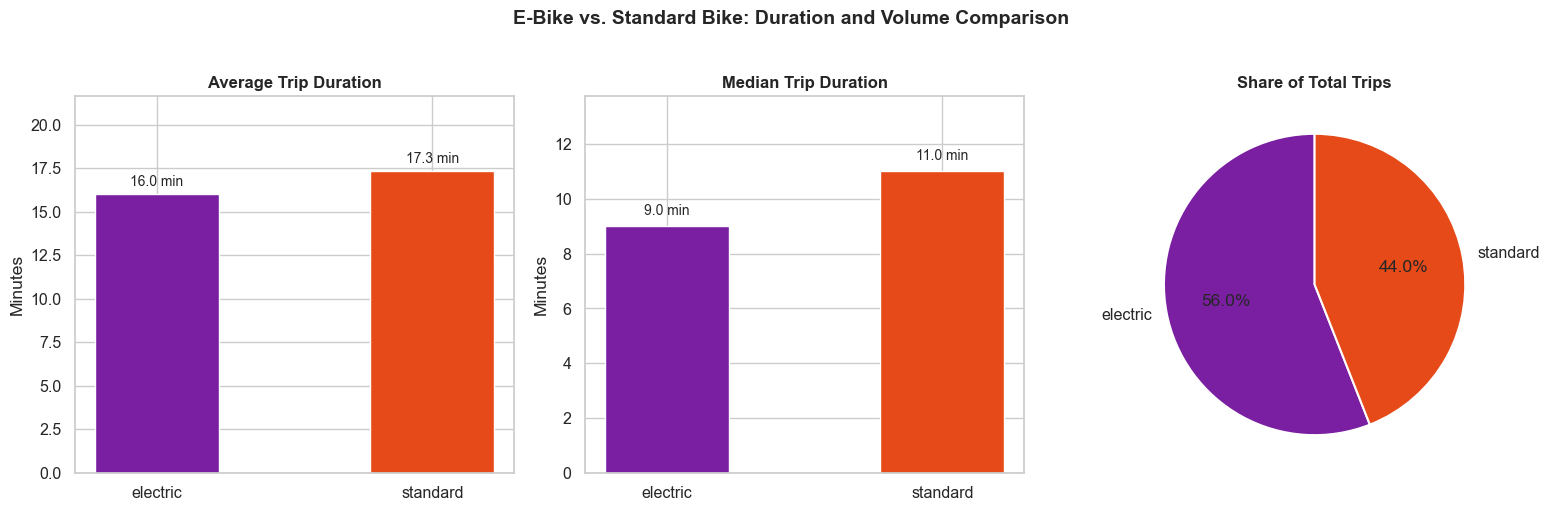


Summary table:
bike_type  avg_duration  median_duration  trip_count
 electric     15.997083              9.0     2584939
 standard     17.318540             11.0     2032961


In [13]:
bike_stats = (
    df.groupby('bike_type')
    .agg(
        avg_duration=('duration', 'mean'),
        median_duration=('duration', 'median'),
        trip_count=('duration', 'count')
    )
    .reset_index()
    .sort_values('bike_type')
)

# Real Indego bike_type values: 'electric' and 'standard'
palette = {'electric': '#7B1FA2', 'standard': '#E64A19'}
colors  = [palette.get(b, '#607D8B') for b in bike_stats['bike_type']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: average duration
axes[0].bar(bike_stats['bike_type'], bike_stats['avg_duration'],
            color=colors, edgecolor='white', width=0.45)
for bar, row in zip(axes[0].patches, bike_stats.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{row.avg_duration:.1f} min',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Minutes')
axes[0].set_title('Average Trip Duration', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, bike_stats['avg_duration'].max() * 1.25)

# Panel B: median duration
axes[1].bar(bike_stats['bike_type'], bike_stats['median_duration'],
            color=colors, edgecolor='white', width=0.45)
for bar, row in zip(axes[1].patches, bike_stats.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{row.median_duration:.1f} min',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Minutes')
axes[1].set_title('Median Trip Duration', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, bike_stats['median_duration'].max() * 1.25)

# Panel C: share of trips
axes[2].pie(
    bike_stats['trip_count'],
    labels=bike_stats['bike_type'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[2].set_title('Share of Total Trips', fontsize=12, fontweight='bold')

plt.suptitle('E-Bike vs. Standard Bike: Duration and Volume Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nSummary table:")
print(bike_stats.to_string(index=False))

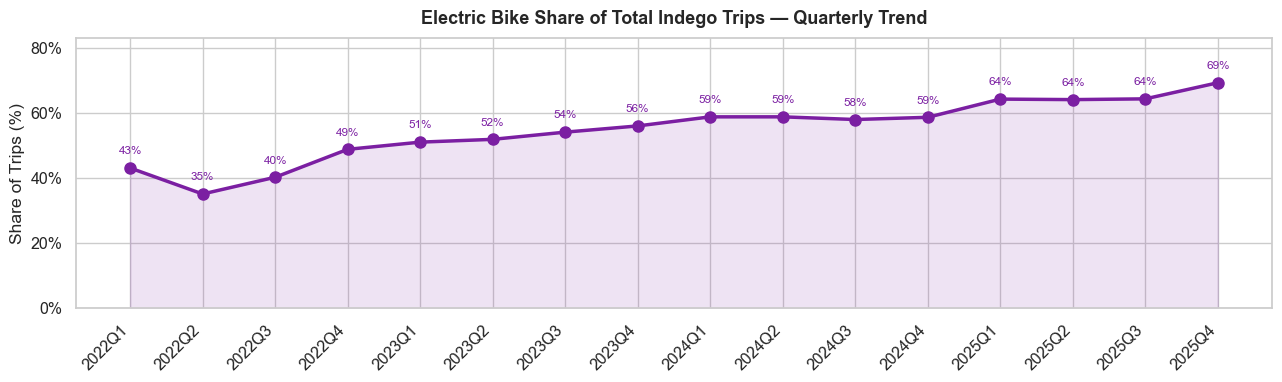

In [14]:
# E-bike adoption trend: quarterly share over time
ebike_trend = (
    df.groupby(['quarter_str', 'bike_type'])
    .size()
    .reset_index(name='trips')
)
total_by_q = df.groupby('quarter_str').size().reset_index(name='total')
ebike_trend = ebike_trend.merge(total_by_q, on='quarter_str')
ebike_trend['share'] = ebike_trend['trips'] / ebike_trend['total'] * 100

# Real Indego bike_type value is 'electric' (not 'electric-assist')
ebike_only = ebike_trend[ebike_trend['bike_type'] == 'electric'].sort_values('quarter_str')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(len(ebike_only)), ebike_only['share'], marker='o',
        linewidth=2.5, markersize=8, color='#7B1FA2')
ax.fill_between(range(len(ebike_only)), ebike_only['share'], alpha=0.12, color='#7B1FA2')

for xi, (_, row) in enumerate(ebike_only.iterrows()):
    ax.annotate(f"{row['share']:.0f}%",
                xy=(xi, row['share']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8.5, color='#7B1FA2')

ax.set_xticks(range(len(ebike_only)))
ax.set_xticklabels(ebike_only['quarter_str'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_ylabel('Share of Trips (%)')
ax.set_title('Electric Bike Share of Total Indego Trips — Quarterly Trend',
             fontsize=13, fontweight='bold', pad=10)
ax.set_ylim(0, ebike_only['share'].max() * 1.2)
plt.tight_layout()
plt.show()

---
## 8. Weather Impact on Ridership

Weather fetched from [Open-Meteo](https://open-meteo.com/) — free, no API key required.
Each point is one day. **Blue = dry day, Red = rain day** (precipitation > 0.1 in).

> **Connection to Notebook 02:** Rain reduces demand by roughly 10–15% with the strongest effect during AM commute. Notebook 02 includes `is_rain_day`, `precip_in`, and a `rain_x_am` interaction feature for this reason — ML achieves **+9.6% lift over baseline on rainy days**.

In [15]:
# Aggregate daily trips
daily_trips = df.groupby('date').size().reset_index(name='trips')
daily_trips['date'] = pd.to_datetime(daily_trips['date'])

# Fetch weather (Open-Meteo, free)
print("Fetching weather from Open-Meteo...")
weather = fetch_weather(
    start_date=str(daily_trips['date'].min().date()),
    end_date=str(daily_trips['date'].max().date())
)
print(f"Weather records: {len(weather)}")

merged = daily_trips.merge(weather, on='date', how='inner')
merged['has_rain'] = merged['precipitation_sum'] > 0.1

print(f"Merged rows: {len(merged)} days")
merged.head(3)

Fetching weather from Open-Meteo...
Weather records: 1461
Merged rows: 1461 days


,date,trips,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,relative_humidity_2m_mean,uv_index_max,has_rain
0,2022-01-01,603,52.5,55.2,48.0,0.736,7.8,98,None,True
1,2022-01-02,1142,53.8,62.5,39.7,0.480,13.5,85,None,True
2,2022-01-03,851,31.3,38.3,24.4,0.268,15.3,53,None,True


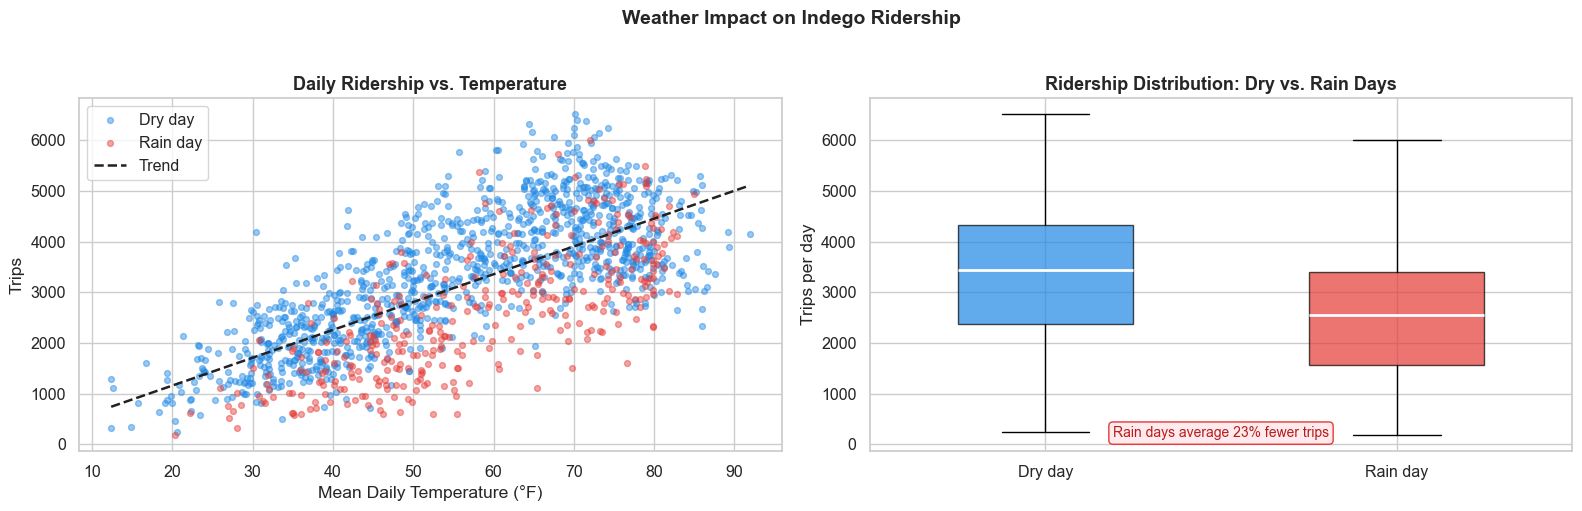

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Panel A: trips vs temperature, coloured by rain ---
dry  = merged[~merged['has_rain']]
rain = merged[merged['has_rain']]

axes[0].scatter(dry['temperature_2m_mean'],  dry['trips'],
                color='#1E88E5', alpha=0.45, s=18, label='Dry day')
axes[0].scatter(rain['temperature_2m_mean'], rain['trips'],
                color='#E53935', alpha=0.45, s=18, label='Rain day')

# Simple regression line
m_val = np.polyfit(merged['temperature_2m_mean'], merged['trips'], 1)
x_line = np.linspace(merged['temperature_2m_mean'].min(),
                     merged['temperature_2m_mean'].max(), 100)
axes[0].plot(x_line, np.polyval(m_val, x_line),
             color='#212121', linewidth=1.8, linestyle='--', label='Trend')

axes[0].set_xlabel('Mean Daily Temperature (°F)')
axes[0].set_ylabel('Trips')
axes[0].set_title('Daily Ridership vs. Temperature', fontsize=13, fontweight='bold')
axes[0].legend()

# --- Panel B: box plot — dry vs rain days ---
plot_data = [
    merged.loc[~merged['has_rain'], 'trips'].values,
    merged.loc[ merged['has_rain'], 'trips'].values
]
bp = axes[1].boxplot(plot_data, patch_artist=True, widths=0.5,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], ['#1E88E5', '#E53935']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Dry day', 'Rain day'])
axes[1].set_ylabel('Trips per day')
axes[1].set_title('Ridership Distribution: Dry vs. Rain Days',
                  fontsize=13, fontweight='bold')

pct_drop = (dry['trips'].mean() - rain['trips'].mean()) / dry['trips'].mean() * 100
axes[1].text(0.5, 0.04,
             f'Rain days average {pct_drop:.0f}% fewer trips',
             transform=axes[1].transAxes, ha='center',
             fontsize=10, color='#B71C1C',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#E53935'))

plt.suptitle('Weather Impact on Indego Ridership', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Most Popular Routes Map

The top 10 start → end station pairs by trip volume. Line thickness scales with popularity. Hover over any line or marker for details.

In [17]:
# Round-trip rides start and end at the same station — exclude them here
# so the routes map shows meaningful point-to-point corridors
routes_df = df[
    df['trip_route_category'] == 'One Way'
].dropna(subset=['start_lat', 'start_lon', 'end_lat', 'end_lon'])

# Exclude trivially short in-place trips (same station)
routes_df = routes_df[routes_df['start_station'] != routes_df['end_station']]

top_routes = (
    routes_df
    .groupby(['start_station', 'end_station',
              'start_lat', 'start_lon', 'end_lat', 'end_lon'])
    .size()
    .reset_index(name='trips')
    .sort_values('trips', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 routes:")
print(top_routes[['start_station', 'end_station', 'trips']].to_string())

Top 10 routes:
   start_station  end_station  trips
0           3020         3032   5402
1           3208         3032   4273
2           3012         3020   3985
3           3020         3012   3618
4           3035         3009   3265
5           3163         3020   3050
6           3054         3102   3010
7           3066         3208   2862
8           3032         3020   2824
9           3009         3035   2812


In [18]:
ROUTE_COLORS = [
    '#E53935', '#8E24AA', '#1E88E5', '#00897B', '#43A047',
    '#F4511E', '#FDD835', '#6D4C41', '#00ACC1', '#3949AB'
]

m_routes = folium.Map(
    location=[39.9526, -75.1652],
    zoom_start=14,
    tiles='CartoDB positron'
)

max_trips = top_routes['trips'].max()

for i, row in top_routes.iterrows():
    color = ROUTE_COLORS[i % len(ROUTE_COLORS)]
    weight = 3 + (row['trips'] / max_trips) * 7

    folium.PolyLine(
        locations=[
            [row['start_lat'], row['start_lon']],
            [row['end_lat'],   row['end_lon']]
        ],
        weight=weight,
        color=color,
        opacity=0.8,
        tooltip=(
            f"<b>Route #{i+1}</b><br>"
            f"Station {row['start_station']} to {row['end_station']}<br>"
            f"{row['trips']:,} trips"
        )
    ).add_to(m_routes)

    # Start station (filled)
    folium.CircleMarker(
        location=[row['start_lat'], row['start_lon']],
        radius=7, color=color, weight=2,
        fill=True, fill_color=color, fill_opacity=0.9,
        tooltip=f"Start: Station {row['start_station']}"
    ).add_to(m_routes)

    # End station (hollow)
    folium.CircleMarker(
        location=[row['end_lat'], row['end_lon']],
        radius=5, color=color, weight=2,
        fill=True, fill_color='white', fill_opacity=0.9,
        tooltip=f"End: Station {row['end_station']}"
    ).add_to(m_routes)

display(HTML(m_routes._repr_html_()))

---
## Key Findings

| Finding | Detail |
|---|---|
| **Growth** | Indego ridership grew consistently 2022–2025, reaching a record 1.3M trips in 2024 |
| **Commuter core** | Weekday 8 am and 5–6 pm peaks dominate; clear two-mode structure in the heatmap |
| **Recreational weekend** | Round-trip rides concentrate on Saturday/Sunday midday — a different user profile |
| **E-bike adoption** | Electric-assist bikes account for a growing share of trips and show distinct duration patterns |
| **Weather sensitivity** | Rain days see materially fewer trips; ridership is strongly correlated with temperature |
| **Popular corridors** | Top routes cluster around Center City and University City station clusters |

---
*Data: Indego Bike Share (Bicycle Transit Systems / City of Philadelphia). Weather: Open-Meteo historical API.*  
*Analysis by Naval Katoch — github.com/nkatoch*